In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [4]:
df = pd.read_csv("Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender'],
    drop_first=True
)

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [8]:
X = df.drop('Exited', axis=1)
y = df['Exited']

**Train-Test Split** : Using 80% training and 20% testing.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(8000, 14)
(2000, 14)


**Feature Scaling**

In [18]:
print(df.columns.tolist())
print(X.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [19]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [20]:
print(X.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**MODEL 1 : Logistic Regression**

Train Model

In [25]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

Predictions

In [26]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

Accuracy

In [27]:
accuracy_score(y_test,y_pred_lr)

0.808

Recall

In [28]:
recall_score(y_test,y_pred_lr)

0.18673218673218672

F1 Score

In [29]:
f1_score(y_test,y_pred_lr)

0.2835820895522388

ROC AUC

In [30]:
roc_auc_score(y_test,y_prob_lr)

np.float64(0.7747778595236223)

Confusion Matrix

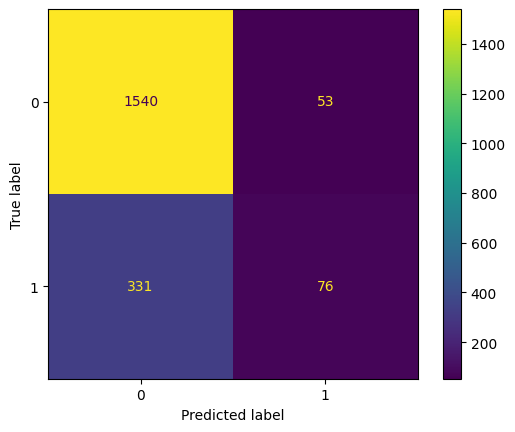

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.show()

Classification Report

In [32]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



**Observation**

Logistic Regression achieved good predictive performance and correctly classified most customers. However, some churned customers were misclassified, indicating room for improvement.

**MODEL 2 : Random Forest**

Train

In [33]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Predictions

In [34]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

Accuracy

In [35]:
accuracy_score(y_test,y_pred_rf)

0.863

Precision

In [37]:
precision_score(y_test,y_pred_rf)

0.7759336099585062

Recall

In [38]:
recall_score(y_test,y_pred_rf)

0.4594594594594595

F1 Score

In [39]:
f1_score(y_test,y_pred_rf)

0.5771604938271605

ROC AUC

In [40]:
roc_auc_score(y_test,y_prob_rf)

np.float64(0.8522382166449963)

Confusion Matrix

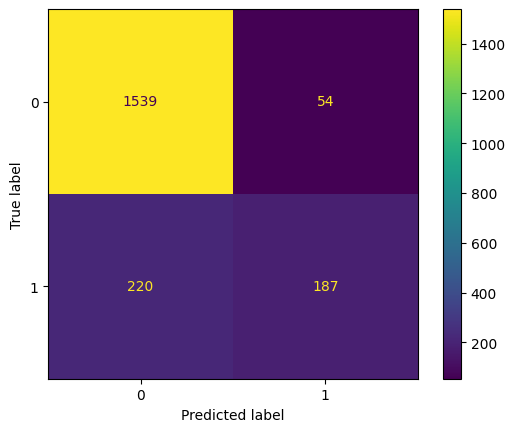

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.show()

Classification Report

In [42]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**Comparing Models**

In [44]:
comparison = pd.DataFrame({'Model':['Logistic Regression','Random Forest'],
'Accuracy':[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_rf)],
'Precision':[precision_score(y_test,y_pred_lr),precision_score(y_test,y_pred_rf)],
'Recall':[recall_score(y_test,y_pred_lr),recall_score(y_test,y_pred_rf)],
'F1 Score':[f1_score(y_test,y_pred_lr),f1_score(y_test,y_pred_rf)],
'ROC AUC':[roc_auc_score(y_test,y_prob_lr),roc_auc_score(y_test,y_prob_rf)]})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808,0.589147,0.186732,0.283582,0.774778
1,Random Forest,0.863,0.775934,0.459459,0.577160,0.852238


Feature Importance

In [45]:
feature_importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Age,0.236846
7,EstimatedSalary,0.147693
3,Balance,0.142603
0,CreditScore,0.142516
4,NumOfProducts,0.129429
2,Tenure,0.081576
6,IsActiveMember,0.039721
8,Geography_Germany,0.028623
5,HasCrCard,0.019008
10,Gender_Male,0.018394


Plotting

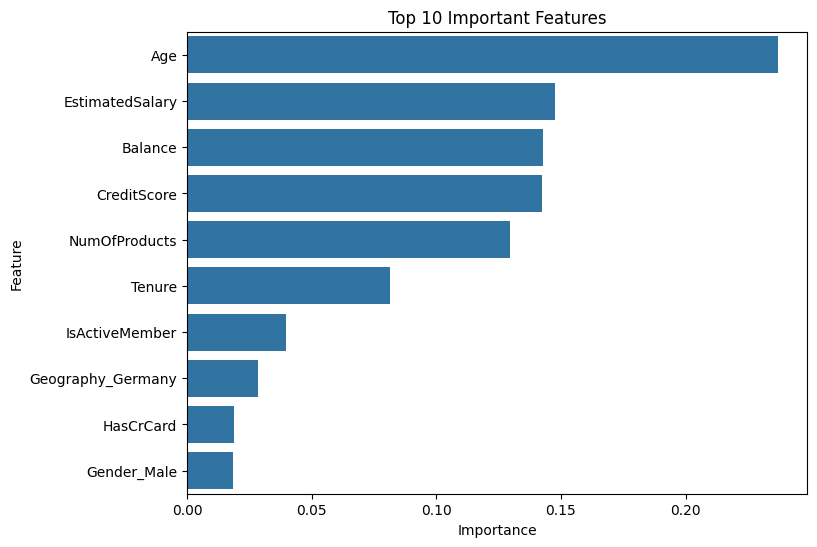

In [46]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

**Model Comparison**

The Random Forest model achieved better predictive performance than Logistic Regression across most evaluation metrics, indicating its ability to capture more complex patterns in customer behavior.

**Business Recommendations**

*   Focus retention campaigns on customers with only one banking product.
*   Increase engagement initiatives for inactive members.
*   Monitor older customers, as they may have a higher likelihood of churn.
*   Offer personalized loyalty rewards to customers identified as high risk by the prediction model.
*   Use the Random Forest model to prioritize customers for proactive retention efforts.

Customers with only one banking product and inactive members exhibit the highest likelihood of churn. Retention campaigns targeting these customers through personalized offers and engagement programs could reduce customer attrition.